In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Depression_Severity_NLP'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/plots', exist_ok=True)

print("✅ Google Drive bağlandı!")
print(f"📁 Proje klasörü: {PROJECT_DIR}")

Mounted at /content/drive
✅ Google Drive bağlandı!
📁 Proje klasörü: /content/drive/MyDrive/Depression_Severity_NLP


In [3]:
!pip install transformers==4.40.0 -q
!pip install datasets -q
!pip install accelerate -q

print("✅ Tüm kütüphaneler kuruldu!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Tüm kütüphaneler kuruldu!


In [4]:
!pip install transformers==4.44.0 -q
!pip install accelerate -q

print("✅ Kurulum tamamlandı! Şimdi Runtime > Restart Runtime yapın!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 51.1 MB/s eta 0:00:00
✅ Kurulum tamamlandı! Şimdi Runtime > Restart Runtime yapın!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings, random, os, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score, accuracy_score)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, EvalPrediction)
from torch.utils.data import Dataset

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU kontrolü
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Cihaz: {device}")
if torch.cuda.is_available():
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU bulunamadı, CPU kullanılacak (eğitim yavaş olabilir)")

✅ Cihaz: cuda
🖥️ GPU: Tesla T4


In [6]:
from google.colab import files

print("📂 CSV dosyasını yükleyin...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)

# Temizlik
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['label'] = df['label'].replace('minimum', 'minimal')

print(f"✅ Dataset yüklendi: {df.shape[0]:,} satır")
print(f"\n📊 Sınıf Dağılımı:")
print(df['label'].value_counts())

📂 CSV dosyasını yükleyin...


Saving Depression_Severity_Levels_Dataset.csv to Depression_Severity_Levels_Dataset.csv
✅ Dataset yüklendi: 41,859 satır

📊 Sınıf Dağılımı:
label
severe      11176
mild        10661
minimal     10549
moderate     9473
Name: count, dtype: int64


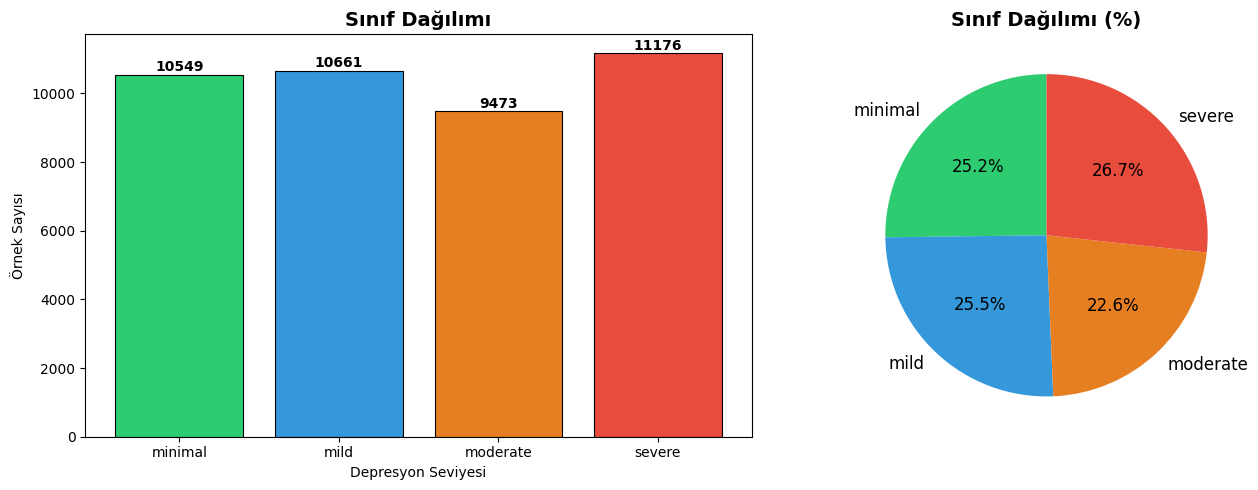

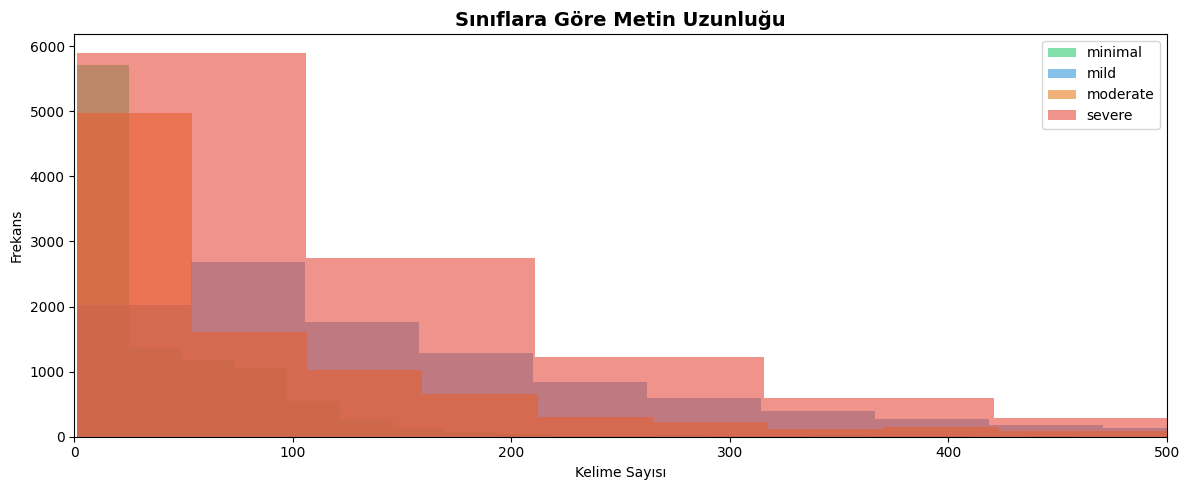


📏 Ortalama metin uzunlukları (kelime):
label
minimal      45.8
mild        177.0
moderate    105.4
severe      155.7
Name: text_length, dtype: float64


In [7]:
PROJECT_DIR = '/content/drive/MyDrive/Depression_Severity_NLP'

label_order = ['minimal', 'mild', 'moderate', 'severe']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts().reindex(label_order)
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depresyon Seviyesi')
axes[0].set_ylabel('Örnek Sayısı')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sınıf Dağılımı (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

df['text_length'] = df['text'].apply(lambda x: len(x.split()))
fig, ax = plt.subplots(figsize=(12, 5))
for i, label in enumerate(label_order):
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=colors[i])
ax.set_title('Sınıflara Göre Metin Uzunluğu', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelime Sayısı')
ax.set_ylabel('Frekans')
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/02_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📏 Ortalama metin uzunlukları (kelime):")
print(df.groupby('label')['text_length'].mean().round(1).reindex(label_order))

In [8]:
label2id = {'minimal': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
id2label = {0: 'minimal', 1: 'mild', 2: 'moderate', 3: 'severe'}

df['label_id'] = df['label'].map(label2id)

# %70 train / %15 val / %15 test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label_id'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_id'])

# Drive'a kaydet
train_df.to_csv(f'{PROJECT_DIR}/train.csv', index=False)
val_df.to_csv(f'{PROJECT_DIR}/val.csv',   index=False)
test_df.to_csv(f'{PROJECT_DIR}/test.csv',  index=False)

print(f"✅ Veri bölme tamamlandı:")
print(f"   Train : {len(train_df):,}")
print(f"   Val   : {len(val_df):,}")
print(f"   Test  : {len(test_df):,}")
print(f"\n💾 Dosyalar Drive'a kaydedildi.")

✅ Veri bölme tamamlandı:
   Train : 29,301
   Val   : 6,279
   Test  : 6,279

💾 Dosyalar Drive'a kaydedildi.


In [9]:
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("✅ DepressionDataset sınıfı tanımlandı.")

✅ DepressionDataset sınıfı tanımlandı.


In [10]:
def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    return {
        'accuracy':  accuracy_score(labels, preds),
        'f1_micro':  f1_score(labels, preds, average='micro'),
        'f1_macro':  f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='micro'),
        'recall':    recall_score(labels, preds, average='micro'),
    }

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix (Sayı)', fontweight='bold')
    axes[0].set_ylabel('Gerçek')
    axes[0].set_xlabel('Tahmin')

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
                xticklabels=label_order, yticklabels=label_order, ax=axes[1])
    axes[1].set_title(f'{model_name} — Confusion Matrix (%)', fontweight='bold')
    axes[1].set_ylabel('Gerçek')
    axes[1].set_xlabel('Tahmin')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plots/{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_training_history(log_history, model_name):
    train_loss, val_loss, val_f1 = [], [], []
    for entry in log_history:
        if 'loss' in entry and 'eval_loss' not in entry:
            train_loss.append(entry['loss'])
        if 'eval_loss' in entry:
            val_loss.append(entry['eval_loss'])
            val_f1.append(entry.get('eval_f1_micro', 0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if train_loss:
        axes[0].plot(train_loss, label='Train Loss', color='#e74c3c', marker='o', markersize=3)
    if val_loss:
        axes[0].plot(val_loss, label='Val Loss', color='#3498db', marker='s', markersize=5)
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Adım')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if val_f1:
        axes[1].plot(val_f1, label='Val F1 (micro)', color='#2ecc71', marker='D', markersize=5)
        axes[1].set_title(f'{model_name} — Validation F1', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('F1 Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plots/{model_name}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Fonksiyonlar hazır.")

✅ Fonksiyonlar hazır.


In [11]:
def train_and_evaluate(model_name, num_epochs=3, batch_size=16, max_len=128, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"🚀 Model: {model_name}")
    print(f"{'='*60}")

    short_name = model_name.split('/')[-1]

    # Tokenizer & Model
    print("📥 Tokenizer ve model yükleniyor...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Dataset
    train_dataset = DepressionDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, max_len)
    val_dataset   = DepressionDataset(val_df['text'].tolist(),   val_df['label_id'].tolist(),   tokenizer, max_len)
    test_dataset  = DepressionDataset(test_df['text'].tolist(),  test_df['label_id'].tolist(),  tokenizer, max_len)

    # Eğitim argümanları
    training_args = TrainingArguments(
        output_dir=f'{PROJECT_DIR}/models/{short_name}',
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_f1_micro',
        logging_steps=100,
        fp16=True,
        seed=SEED,
        report_to='none'
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    # Eğit
    print("🏋️ Eğitim başlıyor...")
    trainer.train()

    # Görseller
    plot_training_history(trainer.state.log_history, short_name)

    # Test
    print("\n📊 Test seti değerlendirmesi...")
    test_results = trainer.predict(test_dataset)
    y_pred = np.argmax(test_results.predictions, axis=1)
    y_true = test_df['label_id'].tolist()

    plot_confusion_matrix(y_true, y_pred, short_name)

    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_order))

    # Sonuçları kaydet
    results = {
        'model':      model_name,
        'accuracy':   float(accuracy_score(y_true, y_pred)),
        'f1_micro':   float(f1_score(y_true, y_pred, average='micro')),
        'f1_macro':   float(f1_score(y_true, y_pred, average='macro')),
        'precision':  float(precision_score(y_true, y_pred, average='micro')),
        'recall':     float(recall_score(y_true, y_pred, average='micro')),
    }

    with open(f'{PROJECT_DIR}/results/{short_name}_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n💾 Sonuçlar kaydedildi.")
    return results

print("✅ train_and_evaluate() fonksiyonu hazır.")

✅ train_and_evaluate() fonksiyonu hazır.


In [12]:
from huggingface_hub import login

# HuggingFace token'ınızı girin
# Token almak için: https://huggingface.co/settings/tokens
login()

In [13]:
import re, unicodedata, html

def e00_raw(text):
    """Ham veri — baseline"""
    if not isinstance(text, str): return ""
    return text.strip()

def e01_html(text):
    """+ HTML varlık çözümleme"""
    text = e00_raw(text)
    return html.unescape(text)

def e02_url(text):
    """+ URL kaldırma"""
    text = e01_html(text)
    return re.sub(r'http\S+|www\S+|https\S+', '', text).strip()

def e03_markdown(text):
    """+ Markdown temizleme"""
    text = e02_url(text)
    return re.sub(r'\*+|#+|`+|_{1,2}|~{2}|\[|\]|\(|\)', '', text).strip()

def e04_char_repeat(text):
    """+ Karakter tekrarı (4+ → 3)"""
    text = e03_markdown(text)
    text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)
    return re.sub(r'([!?.,]){3,}', r'\1\1', text).strip()

def e05_reddit(text):
    """+ Reddit simgeleri (u/, r/)"""
    text = e04_char_repeat(text)
    return re.sub(r'u/\w+|r/\w+', '', text).strip()

def e06_placeholders(text):
    """+ [deleted]/[removed]"""
    text = e05_reddit(text)
    return re.sub(r'\[deleted\]|\[removed\]', '', text, flags=re.IGNORECASE).strip()

def e07_unicode(text):
    """+ Unicode normalleştirme"""
    text = e06_placeholders(text)
    return unicodedata.normalize('NFKC', text).strip()

def e08_punctuation(text):
    """+ Noktalama normalleştirme"""
    text = e07_unicode(text)
    text = re.sub(r'[^\w\s.,!?\'"-]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def e09_whitespace(text):
    """+ Boşluk normalleştirme"""
    text = e08_punctuation(text)
    return re.sub(r'\s+', ' ', text).strip()

def e10_length_filter(text):
    """+ Uzunluk filtresi (min 5 kelime)"""
    text = e09_whitespace(text)
    if len(text.split()) < 5:
        return ""
    return text

def e11_full(text):
    """Full pipeline — hepsi + yineleme kaldırma sonra yapılacak"""
    return e10_length_filter(text)

# Test
sample = "Check out https://reddit.com r/depression u/user123 &amp; **feeling** sooooo bad...... [deleted]"
fns = [e00_raw, e01_html, e02_url, e03_markdown, e04_char_repeat,
       e05_reddit, e06_placeholders, e07_unicode, e08_punctuation, e09_whitespace, e10_length_filter]

for fn in fns:
    print(f"{fn.__name__:20s}: {fn(sample)}")

e00_raw             : Check out https://reddit.com r/depression u/user123 &amp; **feeling** sooooo bad...... [deleted]
e01_html            : Check out https://reddit.com r/depression u/user123 & **feeling** sooooo bad...... [deleted]
e02_url             : Check out  r/depression u/user123 & **feeling** sooooo bad...... [deleted]
e03_markdown        : Check out  r/depression u/user123 & feeling sooooo bad...... deleted
e04_char_repeat     : Check out  r/depression u/user123 & feeling sooo bad.. deleted
e05_reddit          : Check out    & feeling sooo bad.. deleted
e06_placeholders    : Check out    & feeling sooo bad.. deleted
e07_unicode         : Check out    & feeling sooo bad.. deleted
e08_punctuation     : Check out feeling sooo bad.. deleted
e09_whitespace      : Check out feeling sooo bad.. deleted
e10_length_filter   : Check out feeling sooo bad.. deleted


In [14]:
preprocessing_steps = {
    'E00_raw':          e00_raw,
    'E01_html':         e01_html,
    'E02_url':          e02_url,
    'E03_markdown':     e03_markdown,
    'E04_char_repeat':  e04_char_repeat,
    'E05_reddit':       e05_reddit,
    'E06_placeholders': e06_placeholders,
    'E07_unicode':      e07_unicode,
    'E08_punctuation':  e08_punctuation,
    'E09_whitespace':   e09_whitespace,
    'E10_full':         e10_length_filter,
}

datasets_per_step = {}

for name, fn in preprocessing_steps.items():
    temp_df = df.copy()
    temp_df['text'] = temp_df['text'].apply(fn)
    temp_df = temp_df[temp_df['text'] != ''].reset_index(drop=True)

    # Tam yineleme kaldır (E11)
    temp_df = temp_df.drop_duplicates(subset=['text']).reset_index(drop=True)

    train_t, temp_t = train_test_split(temp_df, test_size=0.30, random_state=SEED, stratify=temp_df['label_id'])
    val_t, test_t   = train_test_split(temp_t,  test_size=0.50, random_state=SEED, stratify=temp_t['label_id'])

    datasets_per_step[name] = {
        'train': train_t,
        'val':   val_t,
        'test':  test_t
    }
    print(f"{name}: {len(temp_df):,} satır | train={len(train_t):,} val={len(val_t):,} test={len(test_t):,}")

E00_raw: 32,412 satır | train=22,688 val=4,862 test=4,862
E01_html: 32,412 satır | train=22,688 val=4,862 test=4,862
E02_url: 32,397 satır | train=22,677 val=4,860 test=4,860
E03_markdown: 32,396 satır | train=22,677 val=4,859 test=4,860
E04_char_repeat: 32,395 satır | train=22,676 val=4,859 test=4,860
E05_reddit: 32,394 satır | train=22,675 val=4,859 test=4,860
E06_placeholders: 32,394 satır | train=22,675 val=4,859 test=4,860
E07_unicode: 32,393 satır | train=22,675 val=4,859 test=4,859
E08_punctuation: 32,366 satır | train=22,656 val=4,855 test=4,855
E09_whitespace: 32,366 satır | train=22,656 val=4,855 test=4,855
E10_full: 31,684 satır | train=22,178 val=4,753 test=4,753


In [17]:
ablation_results = {}

for step_name, data in datasets_per_step.items():
    print(f"\n{'='*60}")
    print(f"🚀 {step_name} eğitimi başlıyor...")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained('mental/mental-roberta-base')
    model = AutoModelForSequenceClassification.from_pretrained(
        'mental/mental-roberta-base',
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    train_dataset = DepressionDataset(data['train']['text'].tolist(), data['train']['label_id'].tolist(), tokenizer, 128)
    val_dataset   = DepressionDataset(data['val']['text'].tolist(),   data['val']['label_id'].tolist(),   tokenizer, 128)
    test_dataset  = DepressionDataset(data['test']['text'].tolist(),  data['test']['label_id'].tolist(),  tokenizer, 128)

    training_args = TrainingArguments(
        output_dir=f'{PROJECT_DIR}/models/ablation_{step_name}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_f1_micro',
        logging_steps=100,
        fp16=True,
        seed=SEED,
        report_to='none'
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    test_result = trainer.predict(test_dataset)
    y_pred = np.argmax(test_result.predictions, axis=1)
    y_true = data['test']['label_id'].tolist()

    f1  = float(f1_score(y_true, y_pred, average='micro'))
    acc = float(accuracy_score(y_true, y_pred))

    ablation_results[step_name] = {
        'f1_micro': f1,
        'accuracy': acc
    }

    print(f"✅ {step_name} → F1 Micro: {f1:.4f} | Accuracy: {acc:.4f}")

print("\n🏁 Ablasyon tamamlandı!")


🚀 E00_raw eğitimi başlıyor...


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.572600,0.608527,0.739856,0.739856,0.757127,0.739856,0.739856
2,0.489000,0.574265,0.748713,0.748713,0.769509,0.748713,0.748713
3,0.423400,0.605235,0.750978,0.750978,0.773502,0.750978,0.750978


✅ E09_whitespace → F1 Micro: 0.7580 | Accuracy: 0.7580

🚀 E10_full eğitimi başlıyor...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.649100,0.597879,0.735956,0.735956,0.753709,0.735956,0.735956
2,0.493900,0.611144,0.746897,0.746897,0.764400,0.746897,0.746897
3,0.403700,0.602040,0.753419,0.753419,0.772152,0.753419,0.753419


✅ E10_full → F1 Micro: 0.7650 | Accuracy: 0.7650

🏁 Ablasyon tamamlandı!


📊 Ablasyon Sonuçları:
Adım                   F1 Micro        ΔF1
------------------------------------------
E00_raw                  0.7678    +0.0000
E01_html                 0.7610    -0.0068
E02_url                  0.7642    -0.0036
E03_markdown             0.7669    -0.0009
E04_char_repeat          0.7718    +0.0040
E05_reddit               0.7658    -0.0019
E06_placeholders         0.7658    -0.0019
E07_unicode              0.7681    +0.0003
E08_punctuation          0.7580    -0.0098
E09_whitespace           0.7580    -0.0098
E10_full                 0.7650    -0.0028


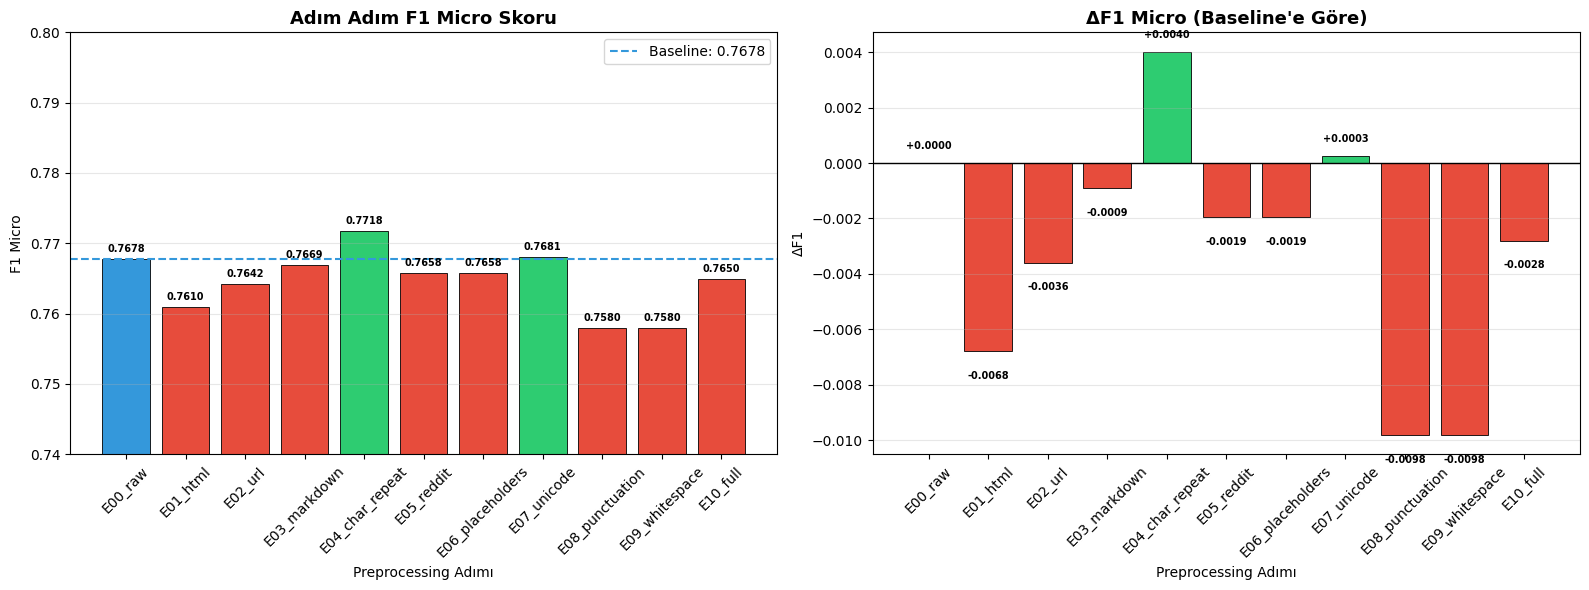


💾 Sonuçlar kaydedildi.


In [18]:
steps = list(ablation_results.keys())
f1_scores = [ablation_results[s]['f1_micro'] for s in steps]
baseline = f1_scores[0]
deltas = [f - baseline for f in f1_scores]

# Tablo
print("📊 Ablasyon Sonuçları:")
print(f"{'Adım':<20} {'F1 Micro':>10} {'ΔF1':>10}")
print("-" * 42)
for step, f1, delta in zip(steps, f1_scores, deltas):
    arrow = f"+{delta:.4f}" if delta >= 0 else f"{delta:.4f}"
    print(f"{step:<20} {f1:>10.4f} {arrow:>10}")

# ---- Görsel 1: F1 Micro per step ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#e74c3c' if d < 0 else '#2ecc71' for d in deltas]
colors_bar[0] = '#3498db'  # baseline mavi

axes[0].bar(steps, f1_scores, color=colors_bar, edgecolor='black', linewidth=0.6)
axes[0].axhline(y=baseline, color='#3498db', linestyle='--', linewidth=1.5, label=f'Baseline: {baseline:.4f}')
axes[0].set_title('Adım Adım F1 Micro Skoru', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Preprocessing Adımı')
axes[0].set_ylabel('F1 Micro')
axes[0].set_ylim(0.74, 0.80)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (v, d) in enumerate(zip(f1_scores, deltas)):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')

# ---- Görsel 2: Delta F1 ----
delta_colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
delta_colors[0] = '#3498db'
axes[1].bar(steps, deltas, color=delta_colors, edgecolor='black', linewidth=0.6)
axes[1].axhline(y=0, color='black', linewidth=1.0)
axes[1].set_title('ΔF1 Micro (Baseline\'e Göre)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Preprocessing Adımı')
axes[1].set_ylabel('ΔF1')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, d in enumerate(deltas):
    axes[1].text(i, d + 0.0005 if d >= 0 else d - 0.001,
                 f'{d:+.4f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# CSV kaydet
ablation_df = pd.DataFrame({
    'step': steps,
    'f1_micro': f1_scores,
    'delta_f1': deltas
})
ablation_df.to_csv(f'{PROJECT_DIR}/results/ablation_results.csv', index=False)
print(f"\n💾 Sonuçlar kaydedildi.")

✅ Dataset hazır: 31,777 satır
   Train: 22,243 | Val: 4,767 | Test: 4,767

🚀 Model: mental/mental-roberta-base
📥 Tokenizer ve model yükleniyor...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Eğitim başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.564500,0.561461,0.739608,0.739608,0.737132,0.739608,0.739608
2,0.510800,0.537201,0.760949,0.760949,0.758357,0.760949,0.760949
3,0.390300,0.673594,0.757923,0.757923,0.757000,0.757923,0.757923
4,0.397200,0.797700,0.753305,0.753305,0.752510,0.753305,0.753305
5,0.275500,0.926085,0.757605,0.757605,0.755718,0.757605,0.757605


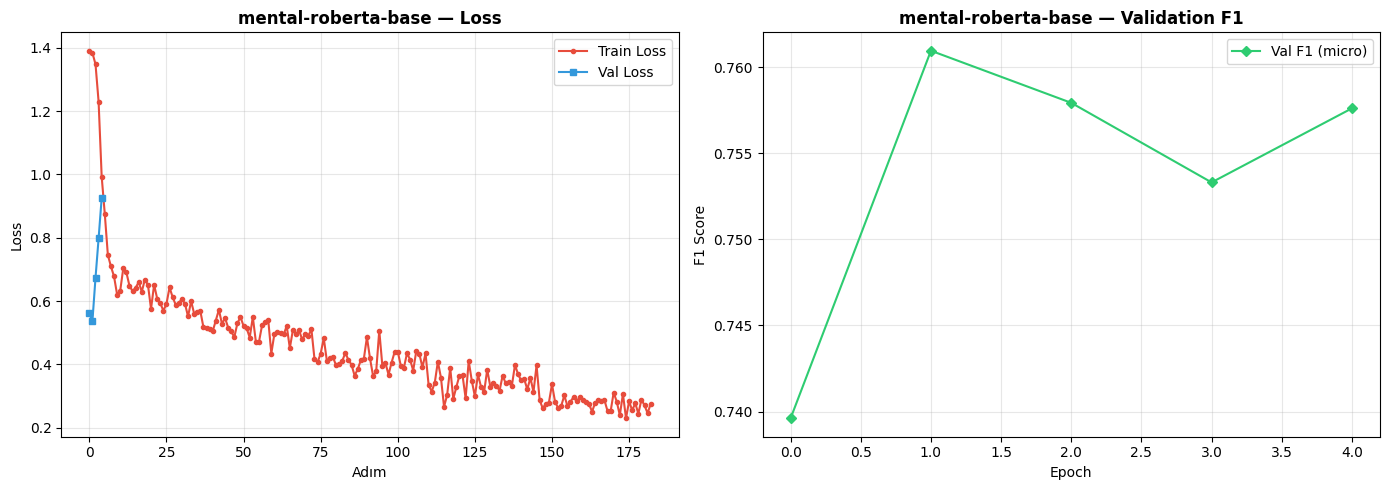


📊 Test seti değerlendirmesi...


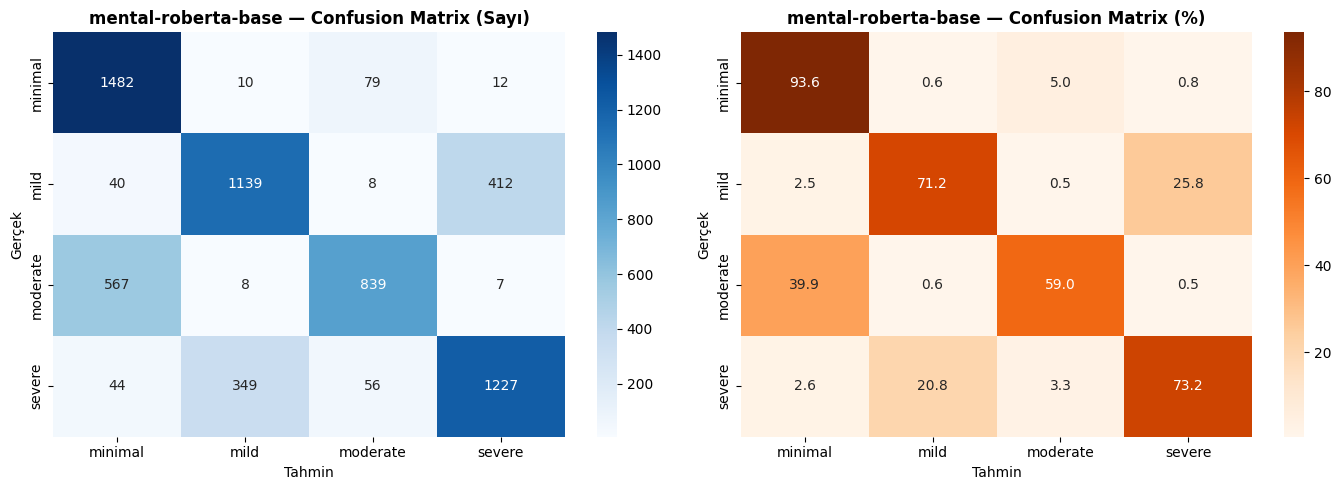


📋 Classification Report:
              precision    recall  f1-score   support

     minimal       0.69      0.94      0.80      1583
        mild       0.76      0.71      0.73      1599
    moderate       0.85      0.59      0.70      1421
      severe       0.74      0.73      0.74      1676

    accuracy                           0.75      6279
   macro avg       0.76      0.74      0.74      6279
weighted avg       0.76      0.75      0.74      6279


💾 Sonuçlar kaydedildi.


In [19]:
def best_preprocess(text):
    """Sadece faydalı adımlar: char_repeat + unicode"""
    if not isinstance(text, str): return ""
    # E04: karakter tekrarı
    text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)
    text = re.sub(r'([!?.,]){3,}', r'\1\1', text)
    # E07: unicode normalleştirme
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text.split()) < 5:
        return ""
    return text

# Dataset oluştur
df_best = df.copy()
df_best['text'] = df_best['text'].apply(best_preprocess)
df_best = df_best[df_best['text'] != ''].drop_duplicates(subset=['text']).reset_index(drop=True)

train_best, temp_best = train_test_split(df_best, test_size=0.30, random_state=SEED, stratify=df_best['label_id'])
val_best, test_best   = train_test_split(temp_best, test_size=0.50, random_state=SEED, stratify=temp_best['label_id'])

print(f"✅ Dataset hazır: {len(df_best):,} satır")
print(f"   Train: {len(train_best):,} | Val: {len(val_best):,} | Test: {len(test_best):,}")

# Eğit
results_best = train_and_evaluate(
    model_name='mental/mental-roberta-base',
    num_epochs=5,
    batch_size=8,
    max_len=256,
    lr=2e-5
)

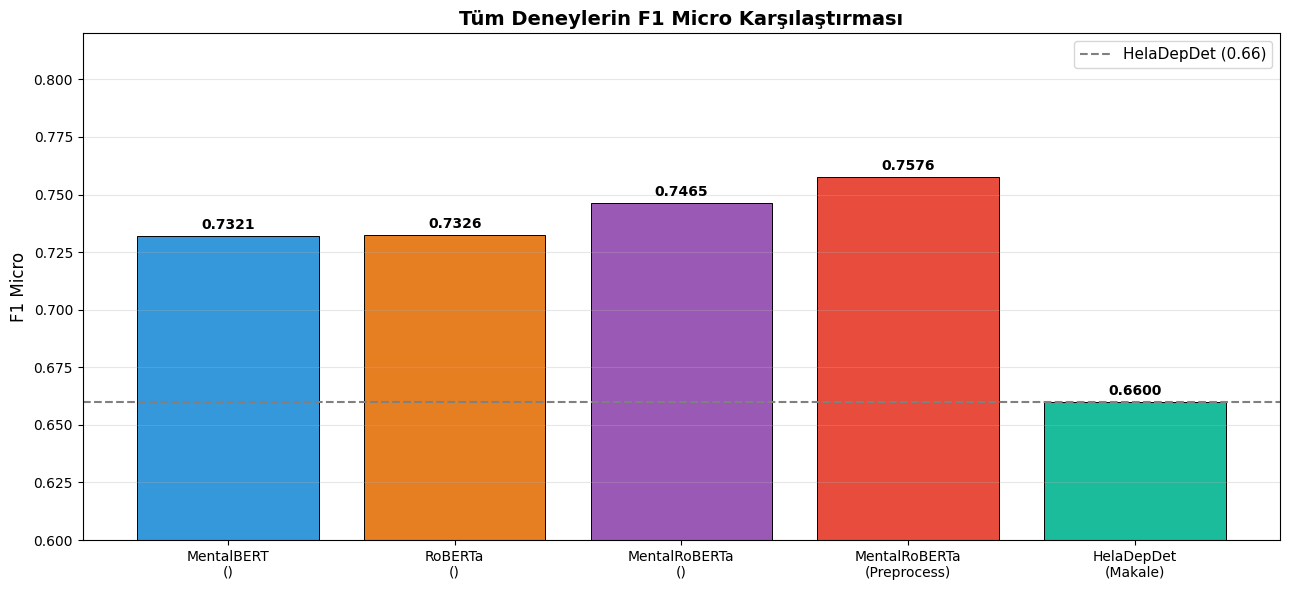


🏆 En iyi model: MentalRoBERTa (Preprocess+256tok)
   F1 Micro    : 0.7576
   HelaDepDet'e göre iyileşme: +0.0976


In [22]:
final_comparison = {
    'MentalBERT\n()':        0.7321,
    'RoBERTa\n()':           0.7326,

    'MentalRoBERTa\n()':     0.7465,
    'MentalRoBERTa\n(Preprocess)':  0.7576,
    'HelaDepDet\n(Makale)':             0.6600,
}

fig, ax = plt.subplots(figsize=(13, 6))
colors_final = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c', '#95a5a6']

bars = ax.bar(final_comparison.keys(), final_comparison.values(),
              color=colors_final, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, final_comparison.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=0.6600, color='gray', linestyle='--', linewidth=1.5, label='HelaDepDet (0.66)')
ax.set_ylabel('F1 Micro', fontsize=12)
ax.set_title('Tüm Deneylerin F1 Micro Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_ylim(0.60, 0.82)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/final_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 En iyi model: MentalRoBERTa (Preprocess+256tok)")
print(f"   F1 Micro    : 0.7576")
print(f"   HelaDepDet'e göre iyileşme: +{0.7576-0.66:.4f}")